In [4]:
# A. DATA IMPORT
# -The dataset was imported into the python environment using pandas for analysis.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("amazon_sales_data.csv")
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,13/04/2022,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,12/03/2023,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,28/09/2022,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,17/04/2022,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,13/03/2022,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [ ]:
## SECTION A --- DATA IMPORT

 **The Amazon sales dataset was loaded using pandas. It contains 50,000 transactions across 13 columns covering;
    order details, product categories, pricing, discounts, regional data, and revenue. The dataset was previewed
    to confirm successful import before analysis began.

In [5]:
# B. DATA OVERVIEW
#- This section examines the structure, data types, and completeness of the dataset.

df.shape
df.info
df.isnull().sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

In [ ]:
## SECTION B --- DATA OVERVIEW

**The dataset was inspected for structure, data types, and missing values. All 13 columns were found
to have appropriate data types for analysis. Missing values were handled before importing into pandas, 
ensuring the data is clean and ready (and data types appropriate for analysis) for explanatory analysis.**

**Note on Terminology**
  The project brief references "Total Sales"as a key metric. In this dataset, the equivalent column is named
    'total_revenue' which represents the total sales value per transaction
    (calculated as discounted_price* quantity_sold). Throughout this analysis, "Total Sales" and 'total_revenue'
    are used interchangeably to maintain consistency between the brief requirements and the dataset column naming.

In [6]:
#1. OVERALL PERFORMANCE

# - This section evaluates total sales and total quantity sold.

total_sales = df['total_revenue'].sum()
total_quantity = df['quantity_sold'].sum()

print(f"Total Sales:${total_sales:,.2f}")
print(f"Total Quantity:{total_quantity}")

Total Sales:$32,866,573.74
Total Quantity:149970


In [ ]:
# SECTION 1 --- OVERALL SALES PERFORMANCE
**FINDIND 1:** The dataset recorded a total revenue of $32, 866,573.74 across units 149,970 sold.
    These figures establish the overall scale of the business and serve as the baseline benchmark for 
    all category, regional, and trend anayses that follow.

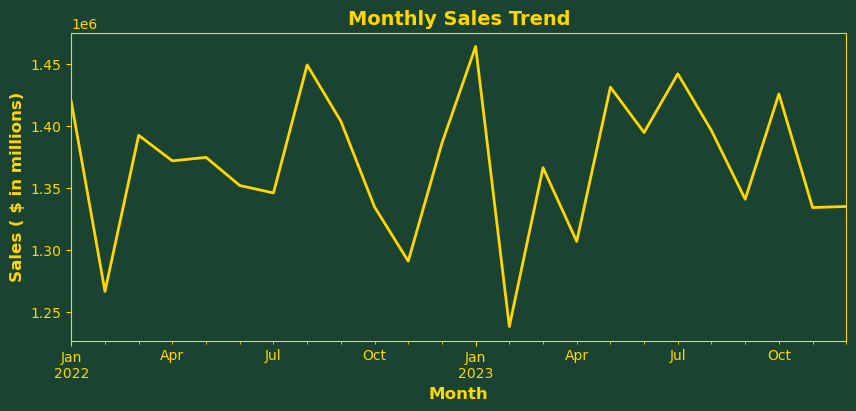

In [7]:
#2. SALES TREND OVER TIME
# - This anaysis examines how sales change over time.

df['order_date'] = pd.to_datetime(df['order_date'], format='%d/%m/%Y')
monthly_sales = df.groupby(df['order_date'].dt.to_period('M'))['total_revenue'].sum()

#Background

import matplotlib.pyplot as plt

fig, ax=plt.subplots(figsize=(10,4)) #width, height

monthly_sales.plot(ax=ax, color='gold', linewidth=2)

fig.patch.set_facecolor('#1b4332')
ax.set_facecolor('#1b4332')

#Title and Labels
plt.title("Monthly Sales Trend", color='gold', fontsize='14', fontweight='bold')
ax.set_xlabel("Month", color='gold', fontsize='12', fontweight='bold')
ax.set_ylabel("Sales ( $ in millions)", color='gold', fontsize='12', fontweight='bold')

#Tick colors (gold)
ax.tick_params(axis='x', colors='gold', which='both')
ax.tick_params(axis='y', colors='gold', which='both')

    
#Border (spines)color
for spine in ax.spines.values():
    spine.set_color('gold')

plt.show()

In [ ]:
## SECTION 2 --- SALES TREND OVER TIME

**FINDING 2:** Monthly revenue fluctuated between approximately $1.27M and $1.45M across January 2022
    to November 2023. A notable peak occurred in January 2023, followed by a sharp dip in
    February 2023- the lowest point in the entire period. Sales recovered strongly through mid-2023 
    with another peak around July 2023. Overall, the trend shows no consistent growth or decline - revenue
    oscillates irregularly, suggesting that sales are influenced by seasonal demand or promotional activity
    rather than steady organic growth.

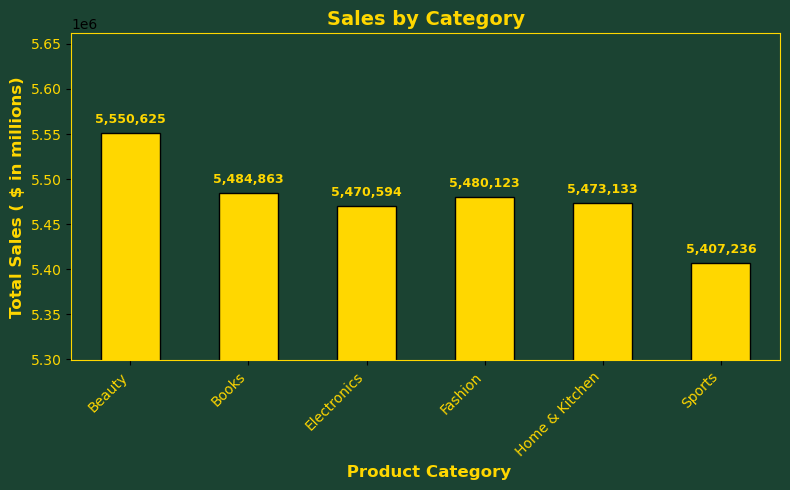

In [8]:
## 3. CATEGORY PERFORMANCE
# - This section identifies which categories generate the most sales.

#Group total revenue by category
ax = product_category = df.groupby('product_category')['total_revenue'].sum().squeeze()

#Create bar chart
ax = product_category.plot(kind ='bar', color = 'gold', edgecolor= 'black', figsize = (8, 5))
ax.set_facecolor('#1b4332')
ax.spines['bottom'].set_color('gold')
ax.spines['left'].set_color('gold')
ax.spines['top'].set_color('gold')
ax.spines['right'].set_color('gold')

#Zoom Y-axis to your data range for clearer differences
plt.ylim(product_category.min()*0.98,product_category.max()*1.02)

#Add title and labels
plt.title ("Sales by Category", fontsize = 14, color='gold', fontweight='bold')
plt.ylabel("Total Sales ( $ in millions)", fontsize = 12, color='gold', fontweight='bold')
plt.xlabel(" Product Category", fontsize=12, color='gold', fontweight='bold')

#Show numbers on top of bars 
for i, v in enumerate(product_category):
    ax.text(i, v + (product_category.max()*0.002), f'{v:,.0f}', ha='center',fontsize=9, color='gold', fontweight='bold')
plt.gcf().set_facecolor('#1b4332')
plt.xticks(rotation=45, ha='right', color='gold')
plt.yticks(color='gold')
plt.tight_layout()
plt.show()

In [ ]:
## SECTION 3 - CATEGORY PERFORMANCE

**Finding:** 
        Beauty is the top-performing category with $5,550,625 in total sales, followed closely by Books ($5,484,863),
        Fashion ($5,480,123), Home & kitchen ($5,473,133), and Electronics ($5,470,594). Sports is the lowest=performing 
        category at $5,407,236. 
    
        However, the revenue (or sales) gap between the highest and lowest categories is relatively narrow - 
        approximately ($143,000), suugestng that all six categories perform at a consistently similar level.
        No single category dominates the business, indicating a well-diversified product portfolio.

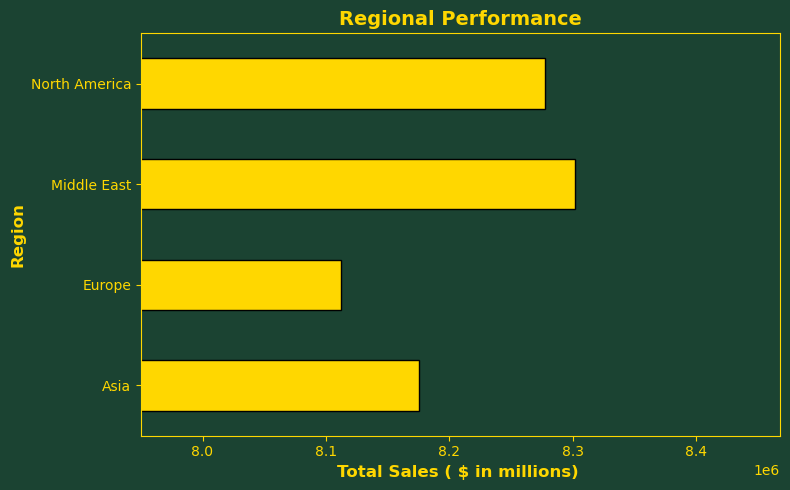

In [9]:
## 4. REGIONAL PERFORMANCE
# - This analysis compares performance across customer regions.

regional = df.groupby('customer_region')['total_revenue'].sum()

fig, ax=plt.subplots(figsize=(8,5))
fig.patch.set_facecolor('#1b4332')
ax.set_facecolor('#1b4332')

regional.plot(kind='barh', color='gold', edgecolor='black', ax=ax)

#Zoom x-axis to show clear difference
ax.set_xlim(regional.min()*0.98, regional.max()*1.02)

plt.title("Regional Performance", color='gold', fontsize='14', fontweight='bold')
ax.set_xlabel("Total Sales ( $ in millions) ", color='gold', fontsize='12', fontweight='bold')
ax.set_ylabel("Region", color='gold', fontsize='12', fontweight='bold')

ax.tick_params(colors='gold')
plt.rcParams['xtick.color']='gold'
plt.rcParams['ytick.color']='gold'

for spine in ax.spines.values():
    spine.set_color('gold')
    
plt.tight_layout()
plt.show()


In [ ]:
## SECTION 4 - REGIONAL ANALYSIS
    
**Finding:** 
    Middle East leads with the highest total sales/total revenue at $8,301,844.50, followed closely
    by North America at $8,277,217.84. Asia sits in third position at $8,175,199.83, while Europe is
    the lowest-performing region at exactly $8.112,311.57.
    
**Which region performs best?** 
    The Middle East is the top-performing region by total sales, though the margin between all four regions is
    relatively narrow at $189,532.93. This suggests that the business has a fairly balanced global presence with
    no single region overwhelmingly driving revenue.
    
**Business Implication:** 
    Despite Europe and Asia trailing slightly, the narrow gap indicates untapped growth potential in these regions
    rather than underperformance - targeted market or regional promotions could close the gap and boost overall
    performance.   

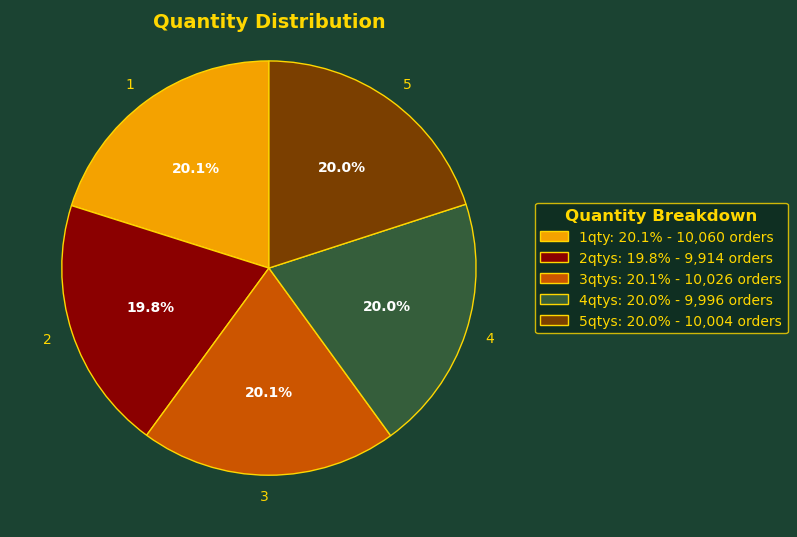

In [10]:
#5. CUSTOMER PURCHASING BEHAVIOUR ANALYSIS

#- This section examines purchasing patterns based on quantity sold.

import matplotlib.pyplot as plt
import pandas as pd

# Prepare data
counts=df['quantity_sold'].value_counts().sort_index()

#Consistent Color Palette
colors = ['#f4a200', '#8b0000', '#cc5500', '#355e3b', '#7b3f00']

fig, ax = plt.subplots(figsize=(12, 5.5))
fig.patch.set_facecolor('#1b4332')
ax.set_facecolor('#1b4332')

wedges, texts, autotexts = ax.pie(
     counts,
     labels =[str(i) for i in counts.index],
     autopct='%1.1f%%',
     startangle=90,
    wedgeprops={'edgecolor': 'gold'},
    colors=colors,
    textprops={'color': 'gold'}
)

#Style the Percentage text inside slices
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

#Legend on the right:
total=counts.sum()
legend_labels = []
for qty, count in counts.items():
    if qty == 1:
            label = 'qty'
    else:
            label = 'qtys'
    legend_labels.append(f"{qty}{label}: {count/total*100:.1f}% - {count:,} orders")

ax.legend(
   wedges,
   legend_labels,
   title= "Quantity Breakdown",
   title_fontsize=11,
   loc='center left',
   bbox_to_anchor = (1,0,0.5,1),
   frameon=True,
   facecolor='#0d2b1f',
   edgecolor='gold',
   labelcolor='gold',
   fontsize=10
)

legend = ax.get_legend()
legend.get_title().set_color('gold')
legend.get_title().set_fontsize(12)
legend.get_title().set_fontweight('bold')

plt.title("Quantity Distribution", color='gold', fontsize='14', fontweight='bold', y=0.95)
plt.tight_layout()
plt.show()


In [ ]:
## SECTION 5 - CUSTOMER PURCHASING BEHAVIOUR ANALYSIS

**Finding:**
    The pie chart reveals an almost perfectly even distribution across all five quantity levels. Single-item orders
    (1 qty) account for 20.1% - 10,060 orders, while 2-item orders represent the lowest share at 19.8% - 9,914 orders.
    Quantities 3,4, and 5 each hold approximately 20% of total orders.

**Distribution of Order Quantities:**
    No single quantity level dominates. Each accounts for roughly one-fifth of all 50,000 orders, with a difference of
    only 146 orders between the highest and lowest groups.
    
**Do Customers tend to buy in small or large quantities?**
    The data shows no clear tendency toward either small or large quantity purchase. Customer buy equally across all
    levels (1 through 5), suggesting that purchasing behaviour is uniformly distributed rather than skewed toward bulk
    or single-unit buying. This may indicate that product type, pricing, or personal need rather than buying habit - 
    drives quantity decisions.   

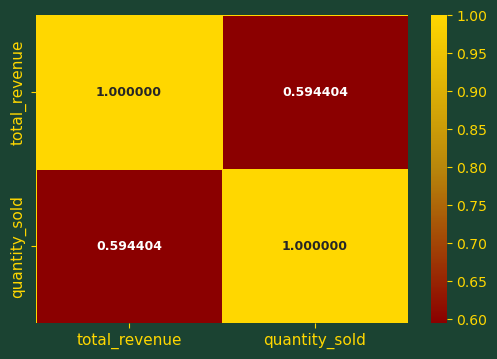

In [11]:
# SECTION 8: CORRELATION ANALYSIS BETWEEN SALES AND QUANTITY SOLD
# - This shows the relationship between the two variables ' total sales/revenue and quantities' 
#   and how much they affect one another.

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.close('all')

custom_cmap = mcolors.LinearSegmentedColormap.from_list(
       'custom', ['#8b0000', '#b8860b', '#ffd700']
)

corr = df[['total_revenue', 'quantity_sold']].corr()

fig, ax=plt.subplots(figsize=(6,4))
fig.patch.set_facecolor('#1b4332')
ax.set_facecolor('#1b4332')
sns.heatmap(corr, annot=True, fmt='2f', cmap = custom_cmap, linewidths=0.5, linecolor='gold', ax=ax
)

for text in ax.texts:
    text.set_fontweight('bold')
    text.set_fontsize(9)
    
ax.tick_params(colors='gold', labelsize=11)
ax.xaxis.label.set_color('gold')

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors='gold')
cbar.ax.yaxis.label.set_color('gold')

plt.show()

In [ ]:
**Finding:**
    The correlation heatmap shows a correlation co-efficient of 0.59 between total_revenue and quantity_sold
    indicating a moderate positive relationship. This means that as the number of units sold increases, total
    revenue (also known as total sales) tends to increase as well. This is expected since revenue/sales is 
    partly a product of quantity.
    
**What is the relationship between Sales and Quantity?**
    The moderate score of 0.59 (rather than astrong 0.80+) reveals that quantity sold alone does not fully determine
    revenue/sales. Other factors - such as product price and discount levels also play a significant role in driving
    total revenue (or total sales). A customer purchasing 1 high-price item may generate more revenue than a customer
    purchasing 5 discounted items.
    
**Business Implicaton:**
    To grow revenue/sales, the business should focus not only on increasing units sold but also on optimising pricing
    and discount strategies, since price per unit significantly influences the total revenue/total sales outcome.